#1. Define Data Quality in the context of ETL pipelines. Why is it more than just data cleaning?

Answer:

Data Quality in ETL (Extract, Transform, Load) refers to the accuracy, completeness, consistency, validity, uniqueness, and reliability of data throughout the ETL process.

It is more than just data cleaning because it also includes:

- Validating data according to business rules.
- Removing duplicate records.
- Maintaining consistency across systems.
- Ensuring data integrity.
- Monitoring and improving data continuously.

Example: If an employee's salary is negative, data cleaning may correct the value, but data quality ensures such invalid records are never loaded into the data warehouse.

#2. Explain why poor data quality leads to misleading dashboards and incorrect decisions.

Answer:

Poor data quality affects business decisions because:

- Incorrect data produces inaccurate reports.
- Duplicate records increase sales or customer counts.
- Missing values create incomplete analysis.
- Invalid data reduces trust in reports.

Example: If duplicate sales records exist, the dashboard may show ₹12,000 sales instead of the actual ₹8,000, leading management to make wrong decisions.

#3.  What is duplicate data? Explain three causes in ETL pipelines.

Answer:

Duplicate data means the same record appears multiple times in a database.

Causes:
1. Multiple data sources importing the same record.
2. ETL job reruns after failure without duplicate checks.
3. Missing unique constraints on business keys.

Example: Customer C101 with the same Product_ID, Date, and Amount appears three times.

#4. Differentiate between exact, partial, and fuzzy duplicates.

Answer:


| Exact Duplicate                                      | Partial Duplicate                 | Fuzzy Duplicate                     |
| ---------------------------------------------------- | --------------------------------- | ----------------------------------- |
| Entire record is identical.                          | Some fields differ.               | Similar but not exactly same.       |
| Easy to detect.                                      | Needs comparison.                 | Requires fuzzy matching algorithms. |
| Example: Same Customer_ID, Product_ID, Date, Amount. | Same customer but different city. | "Rahul Mehta" and "Rahul M."        |


#5. Why should data validation be performed during transformation rather than after loading?

Answer:

Data validation should occur during transformation because:

- Errors are detected before loading.
- Invalid records are prevented from entering the warehouse.
- Saves storage and processing cost.
- Improves report accuracy.
- Makes ETL more reliable.

Example: Reject records where Quantity is NULL before loading.

#6. Explain how business rules help in validating data accuracy. Give an example. Use the following Sales_Transactions dataset for all questions:
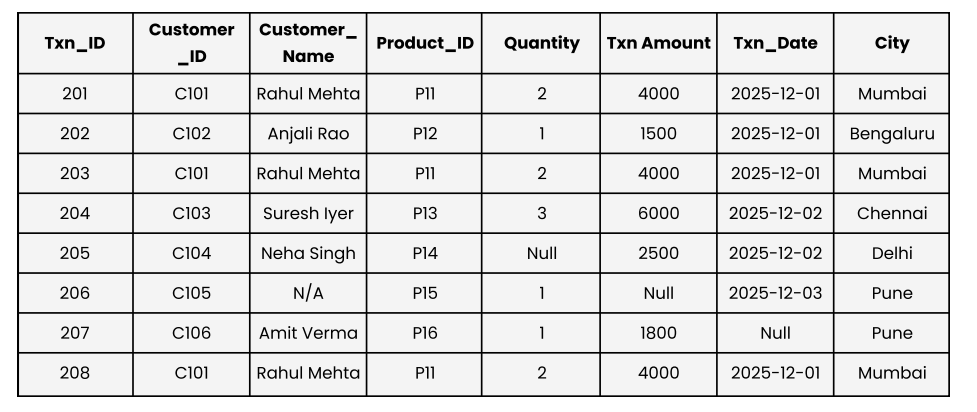

Answer:

Business rules define conditions that data must satisfy.

They help to:

- Validate correctness.
- Maintain consistency.
- Prevent invalid records.
- Improve data quality.

Example Rules:

- Quantity > 0
- Transaction Amount cannot be NULL.
- Customer_ID must exist in Customer Master.

Example: Record with Customer_ID = C105 is invalid because it does not exist in the Customer Master table.



#7. Write an SQL query on sales_transaction to list all duplicate keys and their counts using thebusiness key (Customer_ID + Product_ID + Txn_Date + Txn_Amount )

Answer:
```
SELECT
    Customer_ID,
    Product_ID,
    Txn_Date,
    Txn_Amount,
    COUNT(*) AS Duplicate_Count
FROM Sales_Transactions
GROUP BY
    Customer_ID,
    Product_ID,
    Txn_Date,
    Txn_Amount
HAVING COUNT(*) > 1;
```

Expected Output:

| Customer_ID | Product_ID | Txn_Date   | Txn_Amount | Duplicate_Count |
| ----------- | ---------- | ---------- | ---------- | --------------- |
| C101        | P11        | 2025-12-01 | 4000       | 3               |




#8. Enforcing Referential Integrity Assume the following Customer_Master table: Identify Sales_Transactions.Customer_ID values that violate referential integrity when joined with Customers_Master and write a query to detect such violations.
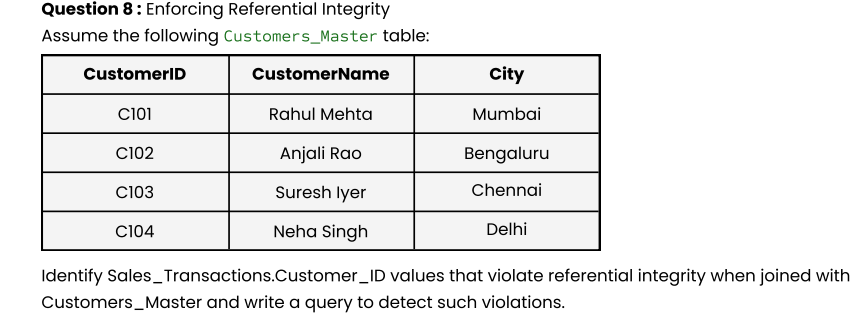

Answer:

```
SELECT
    ST.Customer_ID
FROM Sales_Transactions ST
LEFT JOIN Customers_Master CM
ON ST.Customer_ID = CM.CustomerID
WHERE CM.CustomerID IS NULL;
```
Expected Output

| Customer_ID |
| ----------- |
| C105        |
| C106        |

These Customer_ID values are present in Sales_Transactions but not in Customers_Master, so they violate referential integrity.
